# Customer Segments Based on Income and Spending Score 
This project applies the K-Means clustering algorithm to segment mall customers based on
their Annual Income and Spending Score. The insights can help businesses design targeted 
marketing strategies for different customers groups.

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

#### 1. Data Loading 

In [2]:
dataset= pd.read_csv("Mall_Customers.csv") 

In [3]:
dataset.head() 

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#### 2. Dataset Information

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
dataset.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


#### 3. Feature Selection
  --Selecting Annual Income and Spending Score for customer segmentation 

In [6]:
X = dataset.iloc[:,[3,4]].values           #--Initilization 

In [7]:
X.shape

(200, 2)

#### 4. Feature Scaling
  --since K-Meams uses Euclidean Distance, scaling is required 

In [8]:
from sklearn.preprocessing import StandardScaler 

In [9]:
sc = StandardScaler()            #--Object

In [10]:
X = sc.fit_transform(X)

In [11]:
X[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

#### 5. Finding the Optimal Number of Clusters 
   -- The Elbow Method heaps determine the best value of K 

In [12]:
import warnings 
warnings.filterwarnings("ignore")

In [13]:
from sklearn.cluster import KMeans

In [14]:
wcss = []         # Elbow Method ( WCSS-within cluster sum of squares ) 

In [15]:
for i in range(1,11): 
    kmeans = KMeans(n_clusters=i, init="k-means++", random_state=0)
    kmeans.fit(X) 
    wcss.append(kmeans.inertia_) 

#### 6. Elbow Method Visualization 

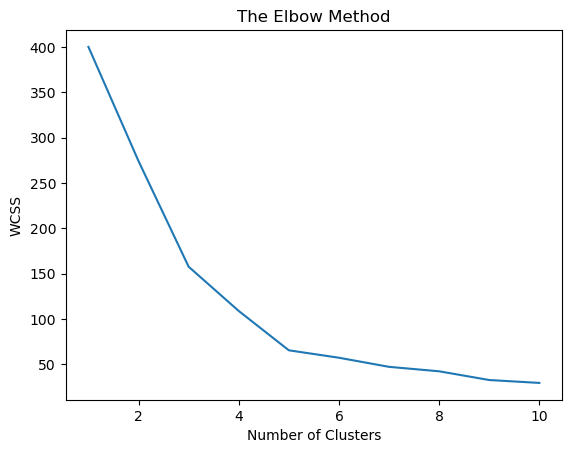

In [16]:
plt.plot(range(1,11),wcss)      # Elbow Method Plot 
plt.title("The Elbow Method")
plt.xlabel("Number of Clusters") 
plt.ylabel("WCSS") 
plt.show() 

#### 7. Traning the K-Means Model 

In [17]:
kmeans = KMeans(n_clusters = 5, random_state = 0) 

In [18]:
kmeans.fit(X) 

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


#### 8. Predicting Customer Segments 

In [19]:
y_cluster = kmeans.predict(X)       #--Prediction 

In [21]:
X1 = X[:,0]
X2 = X[:,1] 

#### 9. Cluster Visualization 

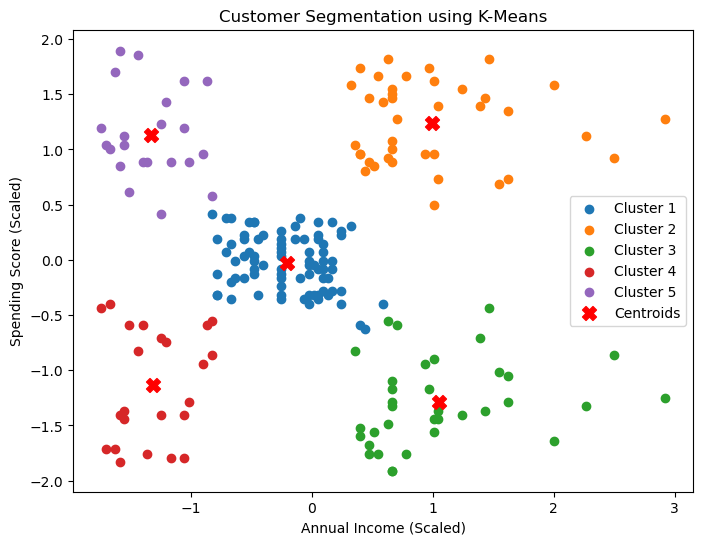

In [22]:
plt.figure(figsize = (8,6))

plt.scatter(X[y_cluster==0,0],X[y_cluster==0,1],label="Cluster 1") 
plt.scatter(X[y_cluster==1,0],X[y_cluster==1,1],label="Cluster 2") 
plt.scatter(X[y_cluster==2,0],X[y_cluster==2,1],label="Cluster 3") 
plt.scatter(X[y_cluster==3,0],X[y_cluster==3,1],label="Cluster 4") 
plt.scatter(X[y_cluster==4,0],X[y_cluster==4,1],label="Cluster 5") 

# Cluster Centers (Centroid) 
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            s=100,
            c='red',
            marker='X',
            label='Centroids')
            
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.title("Customer Segmentation using K-Means") 
plt.legend()
plt.show()

### 10. Business Recommendations 
#### Cluster 1: High Income - High Spending 
Premium membership plans.
Exclusive product recommendations. 
VIP customer rewards. 
#### Cluster 2: High Income - Low Spending 
Encourage purchases using personalized discounts. 
#### Cluster 3: Low Income - High Spending 
Promote affordable offers and seasonal sales.
#### Cluster 4: Low Income - Low Spending 
Target with budget friendly campaigns.
#### Cluster 5: Average Customers 
Increase engagement through loyalty programs. 


### 11. Conclusion 

The K-Means clustering algorithm successfully segmented customers into five distinct groups based on Annual Income 
and Spending Score. 

These customer segments can help businesses:
_Design Personalized marketing campaigns. 
_Improve customer retention. 
_Increase sales through targeted offers. 
_Better understand customer purchasing behavior. 